This notebook demonstrates a simple linear regression analysis using R to model Salary based on Years of Experience.

In [1]:
library(ggplot2)

In [2]:
dataset <- read.csv("../regression_data.csv")

In [3]:
dataset

YearsExperience,Salary
<dbl>,<dbl>
1.1,39343
1.3,46205
1.5,37731
2.0,43525
2.2,39891
2.9,56642
3.0,60150
3.2,54445
3.7,57189


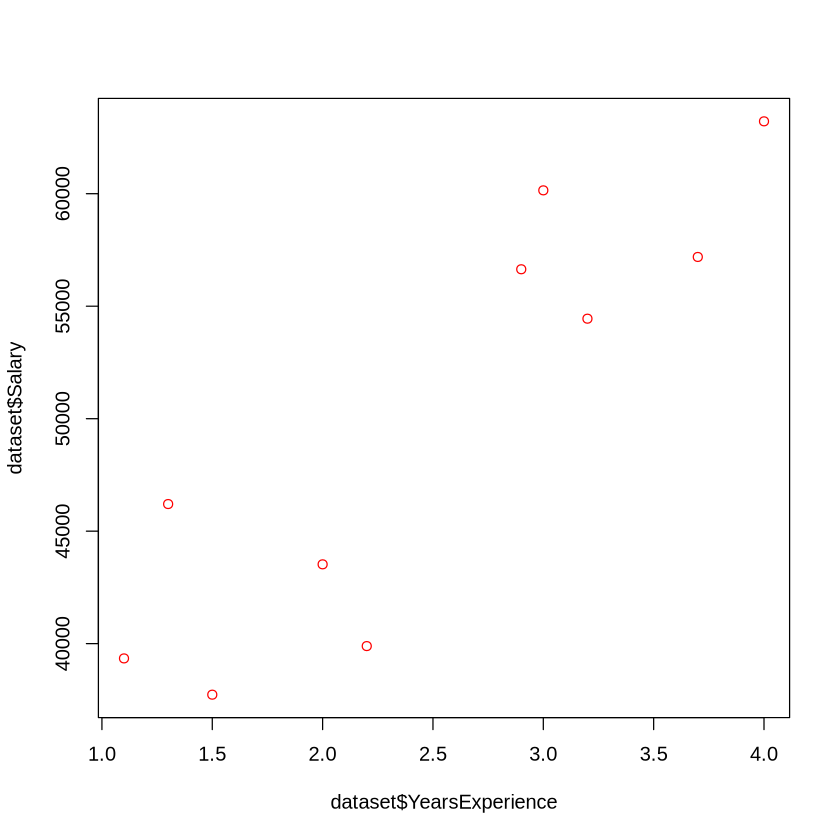

In [4]:
plot(dataset$YearsExperience, dataset$Salary, col='red')

In [18]:
model <- lm(Salary ~ YearsExperience, data=dataset)
slope <- coef(model)[2]
intercept <- coef(model)[1]
r <- cor(dataset$YearsExperience, dataset$Salary)
pred <- predict(model)
mse <- mean((dataset$Salary - pred)^2)

Saving 7 x 7 in image


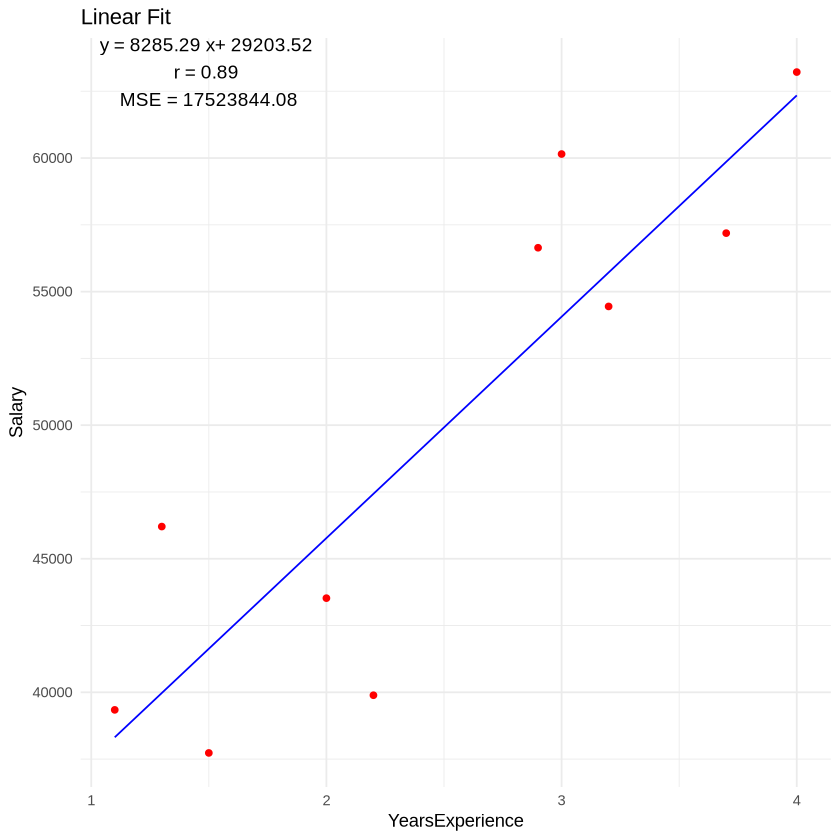

In [23]:
ggplot () +
    geom_point(aes(x = dataset$YearsExperience, y = dataset$Salary), colour = 'red') +
    geom_line(aes(x = dataset$YearsExperience, y = predict(model, newdata = dataset)), colour = 'blue') +
    geom_smooth(method = "lm", se = FALSE, color = 'red') +
    annotate("text", x = 1.5, y = max(dataset$Salary) - 0.5,
             label = paste("y =", round(slope, 2), "x+", round(intercept, 2),
                           "\nr =", round(r, 2), "\nMSE =", round(mse,2)),
             size = 4) +
    labs(title = "Linear Fit",
         x = "YearsExperience", y = "Salary") +
    theme_minimal()
ggsave("regression_plot_r.png")

In [14]:
summary(model)


Call:
lm(formula = Salary ~ YearsExperience, data = dataset)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407
